#### **CORD's ground_truth** field is a raw JSON string. You must parse it and construct a flat text target from the menu array

In [1]:
import json

def extract_cord_text(ground_truth_str: str) -> str:
    """
    Parse CORD ground_truth JSON and build a flat text string
    suitable as a TrOCR decoding target.
    
    CORD structure:
    {
      "gt_parse": {
        "menu": [
          {"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"},
          ...
        ],
        "sub_total": {"subtotal_price": "428,000"},
        "total": {"total_price": "428,000"}
      }
    }
    """
    try:
        parsed = json.loads(ground_truth_str)
        gt = parsed.get("gt_parse", {})
        
        parts = []
        for item in gt.get("menu", []):
            # CORD menu items can be dicts OR plain strings — skip non-dicts
            if not isinstance(item, dict):
                continue
            nm    = item.get("nm", "").strip()
            cnt   = item.get("cnt", "").strip()
            price = item.get("price", "").strip()
            if nm:
                parts.append(f"{nm} {cnt} {price}".strip())
        
        # Optionally append total
        total = gt.get("total", {})
        if isinstance(total, dict) and total.get("total_price", ""):
            parts.append(f"TOTAL {total['total_price']}")
        
        return " | ".join(parts)
    
    except (json.JSONDecodeError, KeyError, AttributeError):
        return ""  # Skip malformed examples

### **SROIE** Text Reconstruction
#### SROIE is loaded from HuggingFace Hub. The words field is a flat list of tokens — join them to build the OCR text target:

In [2]:
def extract_sroie_text(words: list) -> str:
    """
    SROIE provides a flat word list. Reconstruct as space-joined string.
    This is the OCR target: the full visible text of the receipt.
    """
    return " ".join(words)

### Combined Dataset Builder
Images are never held as PIL objects in RAM all at once. Each image is immediately encoded to PNG bytes and stored in the HuggingFace Dataset's Arrow format on disk

In [3]:
import io
import json
from pathlib import Path
from datasets import load_dataset, Dataset, DatasetDict
from PIL import Image

SAVE_PATH = Path("/kaggle/working/smart_stock_dataset")

def pil_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="PNG")
    return buf.getvalue()

def iter_to_dataset(iterator) -> Dataset:
    """
    Convert an iterator of (PIL Image, text) tuples into a Dataset.
    Encodes each image to bytes immediately — never accumulates PIL objects in RAM.
    """
    img_bytes, texts = [], []
    for img, text in iterator:
        img_bytes.append(pil_to_bytes(img))
        texts.append(text)
    return Dataset.from_dict({"image_bytes": img_bytes, "text": texts})

def build_and_save_dataset():
    """
    Build combined CORD + SROIE dataset and save to disk.
    On subsequent runs, loads directly from disk — no reprocessing.
    Processes one split at a time to stay within Kaggle RAM limits.
    """
    if SAVE_PATH.exists():
        print(f"Dataset found at {SAVE_PATH} — loading from disk...")
        return DatasetDict.load_from_disk(str(SAVE_PATH))

    print("Building dataset from scratch...")

    # --- CORD (primary dataset — built first, one split at a time) ---
    print("Loading CORD...")
    cord = load_dataset("naver-clova-ix/cord-v2")

    def cord_iter(split):
        for ex in cord[split]:
            text = extract_cord_text(ex["ground_truth"])
            if text:
                yield ex["image"], text

    cord_train      = iter_to_dataset(cord_iter("train"))
    cord_validation = iter_to_dataset(cord_iter("validation"))
    cord_test       = iter_to_dataset(cord_iter("test"))
    print(f"  CORD train: {len(cord_train)} | val: {len(cord_validation)} | test: {len(cord_test)}")
    del cord

    # --- SROIE (supplementary — train+test appended to respective CORD splits) ---
    print("Loading SROIE...")
    sroie = load_dataset("sizhkhy/SROIE")

    def sroie_iter(split):
        for ex in sroie[split]:
            text = extract_sroie_text(ex["words"])
            if text:
                yield ex["images"], text

    sroie_train = iter_to_dataset(sroie_iter("train"))
    sroie_test  = iter_to_dataset(sroie_iter("test"))
    print(f"  SROIE train: {len(sroie_train)} | test: {len(sroie_test)}")
    del sroie

    # --- Combine and save ---
    # train      = CORD train + SROIE train
    # validation = CORD validation only (SROIE has no val split)
    # test       = CORD test + SROIE test
    from datasets import concatenate_datasets
    dataset_dict = DatasetDict({
        "train":      concatenate_datasets([cord_train, sroie_train]),
        "validation": cord_validation,
        "test":       concatenate_datasets([cord_test, sroie_test]),
    })

    SAVE_PATH.mkdir(parents=True, exist_ok=True)
    dataset_dict.save_to_disk(str(SAVE_PATH))

    print(f"\n✅ Saved to {SAVE_PATH}")
    print(f"   Train:      {len(dataset_dict['train'])}")
    print(f"   Validation: {len(dataset_dict['validation'])}")
    print(f"   Test:       {len(dataset_dict['test'])}")
    return dataset_dict

combined_dataset = build_and_save_dataset()

Building dataset from scratch...
Loading CORD...


  CORD train: 786 | val: 98 | test: 98
Loading SROIE...
  SROIE train: 626 | test: 347


Saving the dataset (0/4 shards):   0%|          | 0/1412 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/98 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/445 [00:00<?, ? examples/s]


✅ Saved to /kaggle/working/smart_stock_dataset
   Train:      1412
   Validation: 98
   Test:       445


#### Expected sizes (pre-augmentation):

Train: ~1,412 examples (786 CORD train + 626 SROIE train)
Validation: ~98 examples (CORD val only)
Test: ~445 examples (98 CORD test + 347 SROIE test)

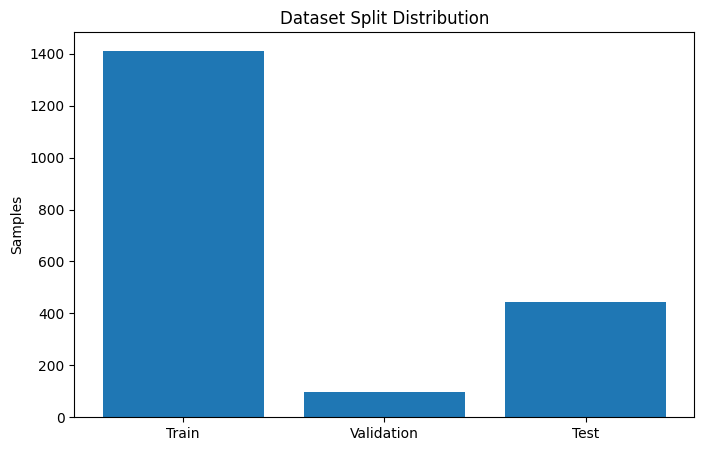

In [6]:
import matplotlib.pyplot as plt

train_size = len(combined_dataset["train"])
val_size   = len(combined_dataset["validation"])
test_size  = len(combined_dataset["test"])

plt.figure(figsize=(8,5))

plt.bar(
    ["Train","Validation","Test"],
    [train_size,val_size,test_size]
)

plt.title("Dataset Split Distribution")
plt.ylabel("Samples")

plt.show()

#### **Augmentation** 
Apply augmentation only to training images, inline during the preprocess_trocr step. The augmentation simulates real-world receipt degradation.

In [8]:
import albumentations as A
import cv2
import numpy as np
from PIL import Image

receipt_augmentation = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.1), p=0.5),  # Thermal fade
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),                       # Scanner noise
    A.Rotate(limit=5, border_mode=cv2.BORDER_REPLICATE, p=0.5),        # Crumple tilt
    A.Perspective(scale=(0.02, 0.05), p=0.3),                          # Photo angle
    A.MotionBlur(blur_limit=3, p=0.2),                                 # Shaky photo
    A.ImageCompression(quality_lower=60, quality_upper=90, p=0.4),     # JPEG artifact
])

def apply_augmentation(pil_image: Image.Image) -> Image.Image:
    """Convert PIL → numpy → augment → PIL."""
    img_np = np.array(pil_image.convert("RGB"))
    augmented = receipt_augmentation(image=img_np)["image"]
    return Image.fromarray(augmented)

/tmp/ipykernel_202/1376373975.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),                       # Scanner noise
/tmp/ipykernel_202/1376373975.py:12: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=60, quality_upper=90, p=0.4),     # JPEG artifact


### Preprocessing Function

In [9]:
import io
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

def preprocess_trocr(example, augment: bool = False):
    """
    Preprocess a single example for TrOCR training.
    
    Args:
        example: dict with keys 'image_bytes' (PNG bytes) and 'text' (str)
        augment: apply receipt degradation augmentation (True for training only)
    
    Returns:
        dict with 'pixel_values' and 'labels' ready for Seq2SeqTrainer
    """
    # Decode from stored bytes — avoids holding all PIL images in RAM
    image = Image.open(io.BytesIO(example["image_bytes"])).convert("RGB")
    
    # Apply augmentation during training
    if augment:
        image = apply_augmentation(image)
    
    # Encode image → pixel_values (ViT expects 384x384)
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    
    # Encode text → token ids
    labels = processor.tokenizer(
        example["text"],
        padding="max_length",
        max_length=128,
        truncation=True,
    ).input_ids
    
    # Replace pad token id with -100 so it's ignored in cross-entropy loss
    labels = [
        token_id if token_id != processor.tokenizer.pad_token_id else -100
        for token_id in labels
    ]
    
    return {
        "pixel_values": pixel_values.squeeze(),
        "labels": labels,
    }

# Apply to datasets — augment train only
train_dataset = combined_dataset["train"].map(
    lambda ex: preprocess_trocr(ex, augment=True),
    remove_columns=["image_bytes", "text"],
    desc="Preprocessing train set",
)
val_dataset = combined_dataset["validation"].map(
    lambda ex: preprocess_trocr(ex, augment=False),
    remove_columns=["image_bytes", "text"],
    desc="Preprocessing val set",
)
test_dataset = combined_dataset["test"].map(
    lambda ex: preprocess_trocr(ex, augment=False),
    remove_columns=["image_bytes", "text"],
    desc="Preprocessing test set",
)

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Preprocessing train set:   0%|          | 0/1412 [00:00<?, ? examples/s]

Preprocessing val set:   0%|          | 0/98 [00:00<?, ? examples/s]

Preprocessing test set:   0%|          | 0/445 [00:00<?, ? examples/s]

### Model Setup

In [ ]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

# Required decoder config — without these the model won't generate properly
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

# Generation config — controls beam search during evaluation
model.config.eos_token_id  = processor.tokenizer.sep_token_id
model.config.max_new_tokens = 128
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

### Training Arguments

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./trocr-smart-stock",
    
    # Training schedule
    num_train_epochs=10,
    per_device_train_batch_size=8,    # Safe for Kaggle T4 (16GB VRAM)
    per_device_eval_batch_size=8,
    
    # Optimizer
    learning_rate=5e-5,
    warmup_steps=500,
    weight_decay=0.01,
    lr_scheduler_type="cosine",       # Better than linear for OCR tasks
    
    # Eval & saving
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,          # Lower CER = better
    save_total_limit=2,               # Keep only 2 checkpoints (Kaggle disk limit)
    
    # Generation
    predict_with_generate=True,
    generation_max_length=128,
    
    # Performance
    fp16=True,                        # Mixed precision — required on T4
    dataloader_num_workers=2,
    
    # Logging
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",                 # Disable wandb on Kaggle
)

### Metrics

In [ ]:
from jiwer import cer, wer

def compute_metrics(pred):
    pred_ids   = pred.predictions
    labels_ids = pred.label_ids
    
    # Decode predictions
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    
    # Replace -100 (padding mask) with pad token id before decoding
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)
    
    return {
        "cer": cer(label_str, pred_str),
        "wer": wer(label_str, pred_str),
    }

### Trainer and Training

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=processor.tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

### Training Curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

print(history.columns)
history.head()

In [ ]:
train_logs = history[history["loss"].notna()]
eval_logs  = history[history["eval_loss"].notna()]

plt.figure(figsize=(12,6))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Training Loss"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("TrOCR Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_cer"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("CER")
plt.title("Character Error Rate per Epoch")
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_wer"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("WER")
plt.title("Word Error Rate per Epoch")
plt.grid(True)

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].plot(eval_logs["epoch"], eval_logs["eval_cer"], marker="o")
axes[0].set_title("CER")
axes[0].set_xlabel("Epoch")

axes[1].plot(eval_logs["epoch"], eval_logs["eval_wer"], marker="o")
axes[1].set_title("WER")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [ ]:
summary = eval_logs[
    ["epoch", "eval_loss", "eval_cer", "eval_wer"]
]

summary

### Save & Export

In [ ]:
import os

# Save best model locally
trainer.save_model("./trocr-smart-stock/best-model")
processor.save_pretrained("./trocr-smart-stock/best-model")

# On Kaggle: save to /kaggle/working/ for persistence
save_path = "/kaggle/working/trocr-smart-stock-best"
trainer.save_model(save_path)
processor.save_pretrained(save_path)
print(f"Model saved to: {save_path}")

### Evaluate on Test Set

In [ ]:
results = trainer.evaluate(test_dataset)
print(f"Test CER: {results['eval_cer']:.4f}")
print(f"Test WER: {results['eval_wer']:.4f}")

# Target benchmarks:
# CER ≤ 0.05 (5%)
# WER ≤ 0.10 (10%)

### Qualitative Evaluation

In [ ]:
sample = combined_dataset["test"][0]

image = sample["image"]

pixel_values = processor(
    image,
    return_tensors="pt"
).pixel_values.to(model.device)

generated_ids = model.generate(pixel_values)

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("GROUND TRUTH:\n")
print(sample["text"])

print("\n")
print("="*80)

print("\nPREDICTION:\n")
print(prediction)

image